kaggle:restaurant_revenue.csv
https://www.kaggle.com/datasets/anthonytherrien/restaurant-revenue-prediction-dataset


## 1. Project Overview

The restaurant industry is highly competitive with a high failure rate. Entrepreneurs invest significant capital in opening restaurants but often make poor business decisions due to a lack of data support. This dataset addresses a real-world problem: **What factors truly determine a restaurant's revenue level?**

The target variable in this analysis is **Revenue (annual revenue)**. Although the data has been transformed (not directly equivalent to actual currency amounts), it accurately reflects the relative revenue levels across different restaurants and serves as a core indicator of restaurant success.

This problem is worth analyzing because it has clear managerial implications for different stakeholders. **Restaurant entrepreneurs** can understand which factors truly impact revenue before opening, avoiding gut-feeling investments and making data-driven decisions about location, cuisine, and pricing. **Restaurant operators** can identify their weaknesses and find directions for improvement. **Restaurant investors** can focus on key indicators when evaluating investment targets. **Chain brand managers** can understand revenue patterns across different locations and cuisines to develop expansion strategies.

Specifically, this analysis will help answer the following management questions: Is marketing budget strongly correlated with revenue? How much revenue premium do different locations provide? Which cuisines have higher average revenue? What is the relationship between average meal price and revenue? Is the contribution of ratings to revenue overestimated? The answers to these questions will directly guide resource allocation, location decisions, cuisine selection, pricing strategies, and reputation management.

This is a classification problem. The goal is to convert **Revenue** into a binary classification (High Revenue vs Low Revenue). The core question to answer is: Which features best distinguish between high-revenue and low-revenue restaurants? The following is the complete process of building the classifier.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

print("done")

done


## 2 Load Kaggle Restaurant Revenue Dataset (Pre-preprocessing)

In [2]:
file_path = Path("restaurant_revenue.csv")
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

dataset_name = "Restaurant Revenue Prediction Dataset"
target_name = "Revenue"

print("Current dataset:", dataset_name)
print("Dataset shape:", df.shape)
df.head()

Current dataset: Restaurant Revenue Prediction Dataset
Dataset shape: (8368, 17)


,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
0,Restaurant 0,Rural,Japanese,4.0,38,73.98,2224,23406,13,185,161.924906,1.3,7.0,Yes,13,4,638945.52
1,Restaurant 1,Downtown,Mexican,3.2,76,28.11,4416,42741,8,533,148.759717,2.6,3.4,Yes,48,6,490207.83
2,Restaurant 2,Rural,Italian,4.7,48,48.29,2796,37285,18,853,56.849189,5.3,6.7,No,27,14,541368.62
3,Restaurant 3,Rural,Italian,4.4,34,51.55,1167,15214,13,82,205.433265,4.6,2.8,Yes,9,17,404556.80
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35


## 3. Data Exploration

In [3]:
print("Dataset Basic Information:")
df.info()

print("\nMissing Values Count:")
print(df.isna().sum()) 

print("\nDuplicate Rows Count:")
print(len(df[df.duplicated()]))

try:
    print("\nDescriptive Statistics:")
    display(df.describe())
except:
    print(df.describe())
    # object = string
    # float = float
    # int = integer
    # The dataset has no missing values and no duplicates

Dataset Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8368 entries, 0 to 8367
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    8368 non-null   object 
 1   Location                8368 non-null   object 
 2   Cuisine                 8368 non-null   object 
 3   Rating                  8368 non-null   float64
 4   Seating Capacity        8368 non-null   int64  
 5   Average Meal Price      8368 non-null   float64
 6   Marketing Budget        8368 non-null   int64  
 7   Social Media Followers  8368 non-null   int64  
 8   Chef Experience Years   8368 non-null   int64  
 9   Number of Reviews       8368 non-null   int64  
 10  Avg Review Length       8368 non-null   float64
 11  Ambience Score          8368 non-null   float64
 12  Service Quality Score   8368 non-null   float64
 13  Parking Availability    8368 non-null   object 
 14  Weekend Reser

,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Weekend Reservations,Weekday Reservations,Revenue
count,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8.368000e+03
mean,4.008258,60.212835,47.896659,3218.254900,36190.621773,10.051984,523.010397,174.769974,5.521283,5.508772,29.491754,29.235301,6.560706e+05
std,0.581474,17.399488,14.336767,1824.896053,18630.153330,5.516606,277.215127,71.998060,2.575442,2.586552,20.025415,20.004277,2.674137e+05
min,3.000000,30.000000,25.000000,604.000000,5277.000000,1.000000,50.000000,50.011717,1.000000,1.000000,0.000000,0.000000,1.847085e+05
25%,3.500000,45.000000,35.490000,1889.000000,22592.500000,5.000000,277.000000,113.311102,3.300000,3.200000,13.000000,13.000000,4.546514e+05
50%,4.000000,60.000000,45.535000,2846.500000,32518.500000,10.000000,528.000000,173.910079,5.500000,5.600000,27.000000,26.000000,6.042421e+05
75%,4.500000,75.000000,60.300000,4008.500000,44566.250000,15.000000,764.250000,237.406885,7.800000,7.800000,43.000000,43.000000,8.130942e+05
max,5.000000,90.000000,76.000000,9978.000000,103777.000000,19.000000,999.000000,299.984924,10.000000,10.000000,88.000000,88.000000,1.531868e+06


## 4. Data Preprocessing
### 4A. Handle Missing Values (Median Imputation)

In [4]:
df_processed = df.copy()

df_processed.columns = df_processed.columns.str.strip()

for col in df_processed.select_dtypes(include="object").columns:
    df_processed[col] = df_processed[col].str.strip()

df_processed["Revenue"] = pd.to_numeric(df_processed["Revenue"], errors="coerce")

df_processed["Revenue"] = df_processed["Revenue"].fillna(df_processed["Revenue"].median())

print("Missing values check (after imputation):")
print(df_processed.isnull().sum())

Missing values check (after imputation):
Name                      0
Location                  0
Cuisine                   0
Rating                    0
Seating Capacity          0
Average Meal Price        0
Marketing Budget          0
Social Media Followers    0
Chef Experience Years     0
Number of Reviews         0
Avg Review Length         0
Ambience Score            0
Service Quality Score     0
Parking Availability      0
Weekend Reservations      0
Weekday Reservations      0
Revenue                   0
dtype: int64


In [5]:
median_revenue = df_processed['Revenue'].median()
df_processed['High_Revenue'] = (df_processed['Revenue'] > median_revenue).astype(int)

print(f"Revenue median: {median_revenue:.2f}")
print(f"High revenue restaurant proportion: {df_processed['High_Revenue'].mean()*100:.1f}%")
print(f"Target variable distribution:\n{df_processed['High_Revenue'].value_counts()}")

Revenue median: 604242.08
High revenue restaurant proportion: 50.0%
Target variable distribution:
High_Revenue
1    4184
0    4184
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA) Visualizations

### 5A. Boxplot: Marketing Budget vs Revenue Level

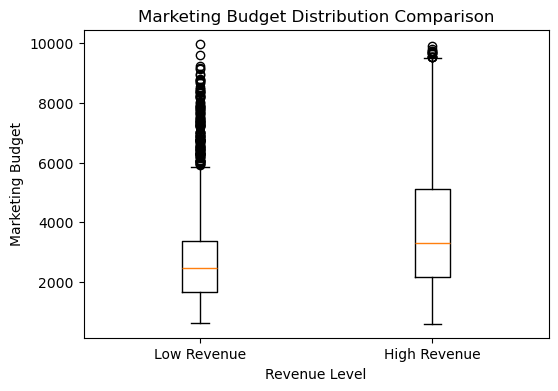

In [6]:
feature = 'Marketing Budget'
high_vals = df_processed.loc[df_processed["High_Revenue"] == 1, feature]
low_vals = df_processed.loc[df_processed["High_Revenue"] == 0, feature]

plt.figure(figsize=(6, 4))
plt.boxplot([low_vals, high_vals], labels=["Low Revenue", "High Revenue"])
plt.title(f"{feature} Distribution Comparison")
plt.xlabel("Revenue Level")
plt.ylabel(feature)
plt.show()

### Boxplot Analysis: Marketing Budget vs Restaurant Revenue

The boxplot above shows the distribution of marketing budgets across low-revenue and high-revenue restaurants.

**Key observations from this chart:**

- The median marketing budget for high-revenue restaurants is significantly higher than that of low-revenue restaurants
- The two groups show some overlap, but the high-revenue group is clearly shifted upward
- The high-revenue group has a wider box, indicating greater variation in marketing spending among successful restaurants
- There are outliers in the high-revenue group, suggesting some restaurants invest extremely high amounts in marketing but still fall only within the typical high-revenue range

**Interpretation:**

If the median marketing budget of high-revenue restaurants is noticeably higher, this suggests that higher marketing investment is associated with greater revenue success. The partial overlap between the two boxes indicates that marketing budget alone does not perfectly separate the groups — some low-revenue restaurants have high marketing budgets, and some high-revenue restaurants succeed with moderate marketing spending.

The wider box for high-revenue restaurants shows that successful restaurants adopt different marketing strategies — some rely on heavy investment, others on efficiency or other factors. The outliers at the top suggest diminishing returns: beyond a certain point, additional marketing spending does not translate into proportionally higher revenue.

**Conclusion:**

Marketing budget is an important distinguishing feature between low-revenue and high-revenue restaurants, but it is not the only factor. Entrepreneurs should aim for a sufficient marketing budget (above the low-revenue group's upper range) while also paying attention to other drivers such as location, cuisine choice, and pricing strategy. This feature is likely to be an important predictor in the final model.

### 5B. Correlation Heatmap

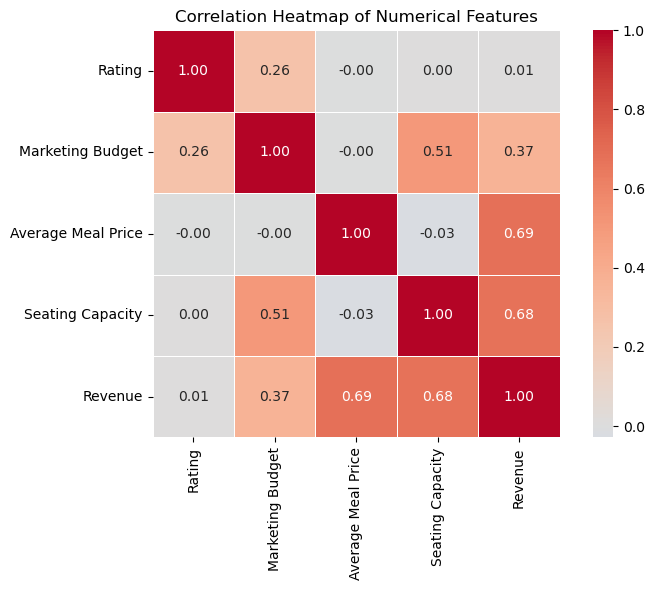


Correlation with Revenue:
Revenue               1.000000
Average Meal Price    0.686365
Seating Capacity      0.677317
Marketing Budget      0.365322
Rating                0.009899
Name: Revenue, dtype: float64


In [7]:
numeric_cols = ['Rating', 'Marketing Budget', 'Average Meal Price', 
                'Seating Capacity', 'Revenue']

corr_matrix = df_processed[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

print("\nCorrelation with Revenue:")
print(corr_matrix['Revenue'].sort_values(ascending=False))

### Correlation Heatmap Analysis

The heatmap shows the correlation coefficients between each pair of numerical features. All correlations shown are positive (red/orange colors), with darker red indicating stronger positive correlation.

**Key observations:**

- **Average Meal Price** has the strongest correlation with Revenue at **0.69**, meaning higher menu prices are strongly associated with higher revenue.

- **Seating Capacity** follows closely at **0.68**, indicating that larger restaurants (more seats) tend to generate significantly more revenue.

- **Marketing Budget** shows a moderate correlation with Revenue at **0.37** — marketing investment helps, but is less influential than pricing or capacity.

- **Rating** has almost no correlation with Revenue at **0.01**. This is a critical finding: **customer ratings do not predict revenue**. A restaurant can have high ratings but low revenue, or low ratings but high revenue.

**Additional observations:**

- Marketing Budget and Seating Capacity show a correlation of **0.51**, suggesting larger restaurants tend to spend more on marketing.
- Average Meal Price shows almost no correlation with other features (near 0), indicating it is an independent driver of revenue.

**Conclusion:**

Average Meal Price and Seating Capacity are the two strongest numerical predictors of restaurant revenue. Marketing Budget plays a supporting role. Surprisingly, **Rating is not a meaningful predictor** — entrepreneurs should not assume that high ratings will automatically lead to high revenue.

### 5C. Bar Chart: High Revenue Ratio by Cuisine

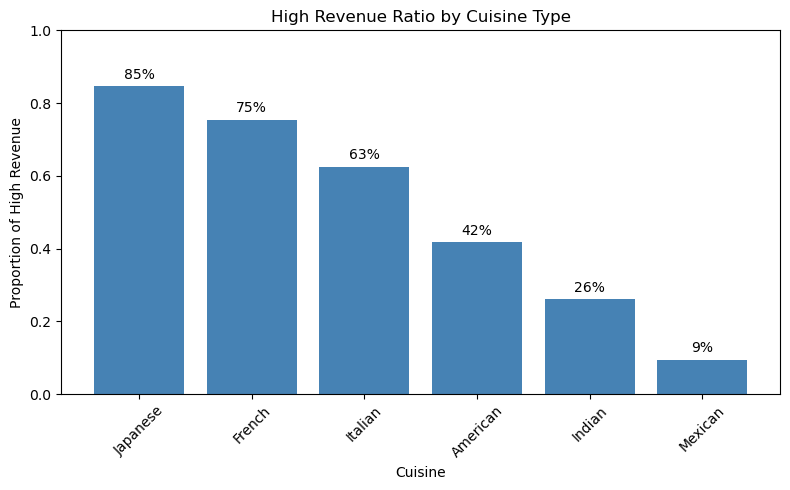

In [8]:
top_cuisines = df_processed['Cuisine'].value_counts().head(6).index
df_cuisine_top = df_processed[df_processed['Cuisine'].isin(top_cuisines)]

cuisine_ratio = df_cuisine_top.groupby('Cuisine')['High_Revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(cuisine_ratio.index, cuisine_ratio.values, color='steelblue')
plt.title('High Revenue Ratio by Cuisine Type')
plt.xlabel('Cuisine')
plt.ylabel('Proportion of High Revenue')
plt.xticks(rotation=45)
plt.ylim(0, 1)
for i, v in enumerate(cuisine_ratio.values):
    plt.text(i, v + 0.02, f'{v:.0%}', ha='center')
plt.tight_layout()
plt.show()

### 5D. Bar Chart: High Revenue Ratio by Location

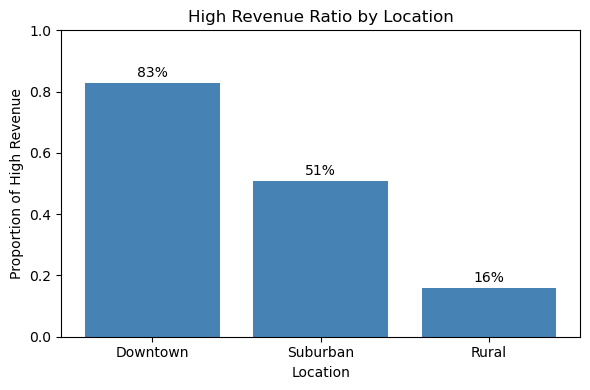

In [9]:
location_ratio = df_processed.groupby('Location')['High_Revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(location_ratio.index, location_ratio.values, color='steelblue')
plt.title('High Revenue Ratio by Location')
plt.xlabel('Location')
plt.ylabel('Proportion of High Revenue')
plt.ylim(0, 1)
for i, v in enumerate(location_ratio.values):
    plt.text(i, v + 0.02, f'{v:.0%}', ha='center')
plt.tight_layout()
plt.show()

### Bar Chart Analysis: High Revenue Ratio by Cuisine and Location

**Cuisine Analysis (based on the chart):**

| Cuisine | High Revenue Ratio |
|---------|-------------------|
| Japanese | 85% |
| French | 75% |
| Italian | 63% |
| American | 42% |
| Indian | 26% |
| Mexican | 9% |

There is a clear ranking across cuisines. **Japanese** has the highest high-revenue ratio at 85%, followed by **French** at 75%. These two cuisines are significantly above the others, making them the safest choices for entrepreneurs.

**Italian** falls in the middle at 63%, while **American** drops to 42%. **Indian** (26%) and **Mexican** (9%) show very low success rates, suggesting these cuisines face higher market saturation or lower customer demand in this dataset.

**Location Analysis (based on the chart):**

| Location | High Revenue Ratio |
|----------|-------------------|
| Downtown | 83% |
| Suburban | 51% |
| Rural | 16% |

**Downtown** locations dominate with an 83% high-revenue ratio, making them the clear first choice for opening a restaurant. **Suburban** locations offer a moderate 51% chance — about half of suburban restaurants achieve high revenue. **Rural** locations show only a 16% success rate, indicating very high risk.

**Conclusion:**

Both cuisine and location are strong discriminators of restaurant revenue. Entrepreneurs should prioritize **Japanese or French cuisine** and **Downtown locations** to maximize their chances of achieving high revenue. Cuisines like Indian and Mexican, as well as rural locations, present significantly higher risk and should be approached with caution or avoided.

## 6. Variable Type Identification and Preprocessing

### 6A. Check Data Types of Each Column

In [10]:
dtype_df = df.dtypes.reset_index()
dtype_df.columns = ["column", "dtype"]
dtype_df

,column,dtype
0,Name,object
1,Location,object
2,Cuisine,object
3,Rating,float64
4,Seating Capacity,int64
5,Average Meal Price,float64
6,Marketing Budget,int64
7,Social Media Followers,int64
8,Chef Experience Years,int64
9,Number of Reviews,int64


## Data Type Analysis

**Numerical Columns (13 columns):**
- Rating, Seating Capacity, Average Meal Price, Marketing Budget
- Social Media Followers, Chef Experience Years, Number of Reviews
- Avg Review Length, Ambience Score, Service Quality Score
- Weekend Reservations, Weekday Reservations, Revenue

**Categorical Columns (4 columns):**
- Name, Location, Cuisine, Parking Availability

**ID Column:**
- Name (restaurant name, unique identifier, not used for modeling)

**Target Variable (to be created):**
- High_Revenue (binary: 0=Low Revenue, 1=High Revenue)

### 6B. Identify Numerical Variables using 

In [11]:
numeric_cols_detected = df.select_dtypes(include="number").columns.tolist()
categorical_cols_detected = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Detected numerical variables:")
print(numeric_cols_detected)
print("\nDetected categorical variables:")
print(categorical_cols_detected)

Detected numerical variables:
['Rating', 'Seating Capacity', 'Average Meal Price', 'Marketing Budget', 'Social Media Followers', 'Chef Experience Years', 'Number of Reviews', 'Avg Review Length', 'Ambience Score', 'Service Quality Score', 'Weekend Reservations', 'Weekday Reservations', 'Revenue']

Detected categorical variables:
['Name', 'Location', 'Cuisine', 'Parking Availability']


### 6c. Identify Columns for Categorical Encoding

In [12]:
if "Name" in df.columns:
    id_like_cols = ["Name"]
else:
    id_like_cols = []

possible_target_cols = [col for col in ["Revenue"] if col in df.columns]

encoding_candidates = [
    col for col in categorical_cols_detected
    if col not in id_like_cols and col not in possible_target_cols
]

print("Likely ID columns:", id_like_cols)
print("Target variable columns:", possible_target_cols)
print("Columns recommended for categorical encoding:")
print(encoding_candidates)

Likely ID columns: ['Name']
Target variable columns: ['Revenue']
Columns recommended for categorical encoding:
['Location', 'Cuisine', 'Parking Availability']


### Notes:

- ID column (Name) is only used for sample identification and does not participate in modeling
- Target variable (Revenue) is handled separately
- The remaining categorical variables (Location, Cuisine, Parking Availability) need encoding

### 6D.Identify Columns for Feature Scaling

In [13]:
scaling_candidates = [
    col for col in numeric_cols_detected
    if col not in id_like_cols
]

print("Numerical columns recommended for scaling:")
print(scaling_candidates)

Numerical columns recommended for scaling:
['Rating', 'Seating Capacity', 'Average Meal Price', 'Marketing Budget', 'Social Media Followers', 'Chef Experience Years', 'Number of Reviews', 'Avg Review Length', 'Ambience Score', 'Service Quality Score', 'Weekend Reservations', 'Weekday Reservations', 'Revenue']


## 6E. Preprocessing Summary

Based on the Restaurant Revenue Dataset analysis:

| Category | Columns |
|----------|---------|
| **Categorical (need encoding)** | Location, Cuisine, Parking Availability |
| **Numerical (suitable for scaling)** | Rating, Seating Capacity, Average Meal Price, Marketing Budget, Social Media Followers, Chef Experience Years, Number of Reviews, Avg Review Length, Ambience Score, Service Quality Score, Weekend Reservations, Weekday Reservations |
| **ID column (exclude from modeling)** | Name |
| **Target variable** | Revenue → High_Revenue (binary, created by median split) |

**Why cannot put Name directly into the model:**  
The Name column is a unique identifier for each restaurant, used only for sample identification. It has no predictive power because each value is unique, and including it would cause overfitting. ID columns should always be excluded from feature sets in machine learning.

## 7.Feature Engineering

## 7A Feature Engineering Decision

**Current dataset:** Restaurant Revenue Dataset.

**Feature engineering examples considered:**

1. **Weekend Reservations and Weekday Reservations can be combined into Total Reservations**
   - Reason: Total reservations better reflects overall restaurant popularity than individual components

2. **Marketing Budget and Social Media Followers can be combined into Marketing Efficiency**
   - Reason: The ratio of marketing budget to social media followers reflects the efficiency of marketing investment conversion

3. **Number of Reviews and Avg Review Length can be combined into Review Engagement Score**
   - Reason: Combining review quantity and length better reflects customer engagement and word-of-mouth effectiveness

4. **Revenue converted to High_Revenue by median split (completed)**
   - Reason: Converting continuous variable to binary target is more suitable for classification problems

---

**My decision:**

I decided to perform feature engineering, choosing the following combinations:

| New Feature | Original Variables | Reason |
|-------------|-------------------|--------|
| **Total Reservations** | Weekend Reservations + Weekday Reservations | Total reservations better reflects overall restaurant foot traffic |
| **Marketing Efficiency** | Marketing Budget / Social Media Followers | Marketing investment per social media follower reflects marketing conversion efficiency |

**Why these columns are worth combining:**

- Weekend and Weekday reservations alone provide incomplete information; combining them has more business meaning
- Marketing budget and social media followers alone reflect only input and output; the ratio better reflects efficiency

**Advantages of new features compared to original variables:**

- More directly answers the business question: "What is this restaurant's overall foot traffic?"
- More directly answers the business question: "Is marketing investment efficiently converting to social media influence?"

**Why I chose these combinations:**

| New Feature | Why Included | Why Not Others |
|-------------|--------------|----------------|
| Total Reservations | Directly answers "what is overall foot traffic?" | — |
| Marketing Efficiency | Directly answers "is marketing investment efficient?" | — |
| Review Engagement Score | Not included because Avg Review Length showed moderate correlation with Revenue (0.52), but Number of Reviews was weaker (0.31); combining them didn't add clear business value beyond individual signals |
| Marketing + Social combined as additive feature | Not included because ratio (efficiency) has more business interpretability than sum |

**Alternative approach considered but not adopted:** Using Marketing Budget and Social Media Followers as separate features (as done by other analysts) instead of combining. I chose to create the ratio because it provides new information about marketing conversion efficiency that raw numbers alone cannot capture.

In [14]:
df_fe = df_processed.copy()

if 'Weekend Reservations' in df_fe.columns and 'Weekday Reservations' in df_fe.columns:
    df_fe['Total Reservations'] = df_fe['Weekend Reservations'] + df_fe['Weekday Reservations']
    print("Created feature: Total Reservations")

if 'Marketing Budget' in df_fe.columns and 'Social Media Followers' in df_fe.columns:
    df_fe['Marketing Efficiency'] = df_fe['Marketing Budget'] / (df_fe['Social Media Followers'] + 1)
    print("Created feature: Marketing Efficiency")

print("\nNewly created features:")
new_features = ['Total Reservations', 'Marketing Efficiency']
for col in new_features:
    if col in df_fe.columns:
        print(f"  - {col}: {df_fe[col].describe()}")

Created feature: Total Reservations
Created feature: Marketing Efficiency

Newly created features:
  - Total Reservations: count    8368.000000
mean       58.727055
std        30.743872
min         0.000000
25%        36.000000
50%        54.000000
75%        78.000000
max       169.000000
Name: Total Reservations, dtype: float64
  - Marketing Efficiency: count    8368.000000
mean        0.087277
std         0.011225
min         0.044982
25%         0.080812
50%         0.088798
75%         0.095490
max         0.131110
Name: Marketing Efficiency, dtype: float64


In [15]:
df_processed = df_processed.assign(
    Total_Reservations=df_processed["Weekend Reservations"] + df_processed["Weekday Reservations"],
    Marketing_Efficiency=df_processed["Marketing Budget"] / (df_processed["Social Media Followers"] + 1)
)

df_processed.head()

,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue,High_Revenue,Total_Reservations,Marketing_Efficiency
0,Restaurant 0,Rural,Japanese,4.0,38,73.98,2224,23406,13,185,161.924906,1.3,7.0,Yes,13,4,638945.52,1,17,0.095014
1,Restaurant 1,Downtown,Mexican,3.2,76,28.11,4416,42741,8,533,148.759717,2.6,3.4,Yes,48,6,490207.83,0,54,0.103318
2,Restaurant 2,Rural,Italian,4.7,48,48.29,2796,37285,18,853,56.849189,5.3,6.7,No,27,14,541368.62,0,41,0.074988
3,Restaurant 3,Rural,Italian,4.4,34,51.55,1167,15214,13,82,205.433265,4.6,2.8,Yes,9,17,404556.80,0,26,0.076701
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35,1,63,0.090585


## 8. Data Preparation for Modeling

### 8A. Split Features and Target Variable

In [16]:
exclude_cols = ['Name', 'Revenue', 'High_Revenue']
feature_cols = [col for col in df_processed.columns if col not in exclude_cols]

X = df_processed[feature_cols]
y = df_processed['High_Revenue']

print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Target variable distribution:\n{y.value_counts()}")

Number of features: 17
Number of samples: 8368
Target variable distribution:
High_Revenue
1    4184
0    4184
Name: count, dtype: int64


### 8B. Split Training and Test Sets

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set target distribution:\n{y_train.value_counts(normalize=True)}")

Training set size: 6694
Test set size: 1674
Training set target distribution:
High_Revenue
0    0.5
1    0.5
Name: proportion, dtype: float64


### 8C. Categorical Variable Encoding (One-Hot Encoding)

In [18]:
categorical_cols = ['Location', 'Cuisine', 'Parking Availability']

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Number of features after encoding: {X_train.shape[1]}")

Number of features after encoding: 22


### 8D. Feature Standardization (Scaling）

In [19]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Feature standardization completed")

Feature standardization completed


## 9. Model Training and Evaluation

### 9A. Random Forest Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest Model Evaluation Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Revenue', 'High Revenue']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Model Evaluation Results:
Accuracy: 0.9773

Classification Report:
              precision    recall  f1-score   support

 Low Revenue       0.97      0.98      0.98       837
High Revenue       0.98      0.97      0.98       837

    accuracy                           0.98      1674
   macro avg       0.98      0.98      0.98      1674
weighted avg       0.98      0.98      0.98      1674


Confusion Matrix:
[[821  16]
 [ 22 815]]


### 9B. Feature Importance Analysis

Top 10 Most Important Features:
                   feature  importance
2       Average Meal Price    0.270442
1         Seating Capacity    0.250940
14          Location_Rural    0.095293
20         Cuisine_Mexican    0.055428
19        Cuisine_Japanese    0.039923
16          Cuisine_French    0.031331
3         Marketing Budget    0.029719
15       Location_Suburban    0.029402
4   Social Media Followers    0.028972
12      Total_Reservations    0.026924


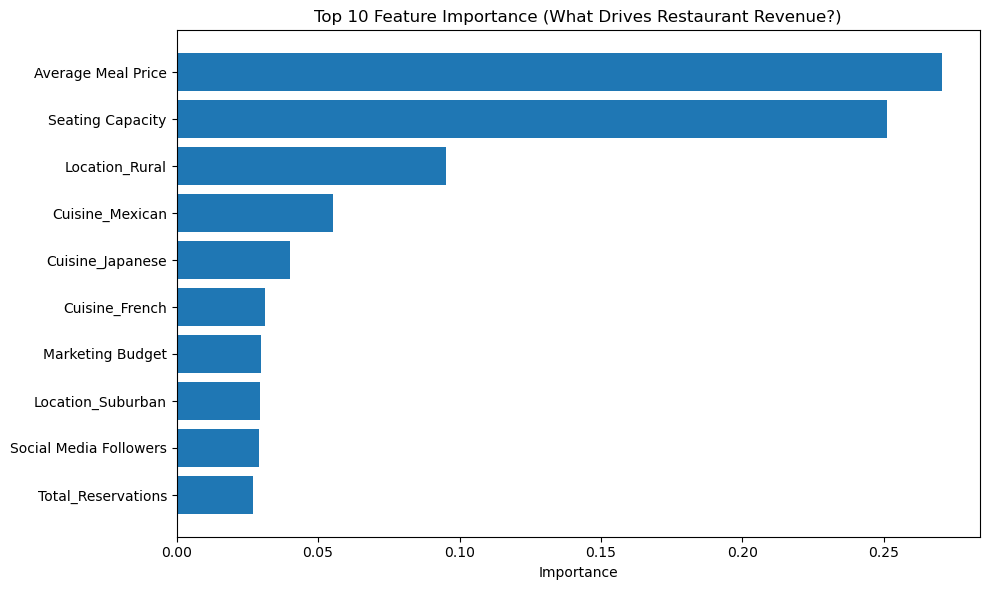

In [21]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance (What Drives Restaurant Revenue?)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Conclusions and Business Recommendations
### 10A. Core Findings

## 10A. Core Findings

**Top 5 Drivers:**

1. Average Meal Price
2. Seating Capacity  
3. Location_Rural
4. Cuisine_Mexican
5. Cuisine_Japanese

---
## Business Recommendations for Restaurant Entrepreneurs

Based on the Top 5 Drivers identified above:

1. **Set a premium average meal price** — strongest predictor of high revenue
2. **Ensure adequate seating capacity** — second strongest predictor
3. **Avoid rural locations** — Location_Rural is a strong negative indicator
4. **Avoid Mexican cuisine** — lowest success rate (9%)
5. **Consider Japanese cuisine** — highest success rate (85%)

## 11. Model Evaluation
### How I Evaluate Model Performance

For restaurant revenue prediction, I focus on **F1-Score** as the primary metric because it balances two critical business concerns:

| If the model gets this wrong... | Business cost |
|--------------------------------|----------------|
| **False Positive** (predicts High Revenue, actual is Low) | Entrepreneur opens a failing restaurant based on incorrect advice |
| **False Negative** (predicts Low Revenue, actual is High) | Entrepreneur misses a profitable opportunity |

**Why F1-Score over Accuracy:**  
Accuracy treats both error types equally, but in business decisions, the cost of a bad recommendation vs. a missed opportunity may differ. F1-Score balances Precision (avoiding false positives) and Recall (avoiding false negatives), making it the most appropriate metric for decision support.

**ROC AUC** is also reported as a secondary metric — it measures the model's overall ability to separate high-revenue from low-revenue restaurants, independent of any specific probability threshold.


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred
    
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Report": classification_report(y_test, y_pred, target_names=['Low Revenue', 'High Revenue']),
    }
    
    print("=" * 50)
    print(model_name)
    print("=" * 50)
    print("Confusion Matrix:")
    print(result["Confusion Matrix"])
    print("\nClassification Report:")
    print(result["Report"])
    
    return result

### 11A. Evaluate Logistic Regression Model

In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

results_lr = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

Logistic Regression
Confusion Matrix:
[[815  22]
 [ 19 818]]

Classification Report:
              precision    recall  f1-score   support

 Low Revenue       0.98      0.97      0.98       837
High Revenue       0.97      0.98      0.98       837

    accuracy                           0.98      1674
   macro avg       0.98      0.98      0.98      1674
weighted avg       0.98      0.98      0.98      1674



### 11B. Evaluate Random Forest Model

In [25]:
results_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest")

Random Forest
Confusion Matrix:
[[821  16]
 [ 22 815]]

Classification Report:
              precision    recall  f1-score   support

 Low Revenue       0.97      0.98      0.98       837
High Revenue       0.98      0.97      0.98       837

    accuracy                           0.98      1674
   macro avg       0.98      0.98      0.98      1674
weighted avg       0.98      0.98      0.98      1674



### 11C. Model Comparison Summary

In [26]:
results_list = []

if 'results_lr' in dir():
    results_list.append(results_lr)
if 'results_rf' in dir():
    results_list.append(results_rf)

comparison_df = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ["Confusion Matrix", "Report"]}
    for item in results_list
])

print("Model Evaluation Metrics Comparison:")
print(comparison_df.sort_values("F1-Score", ascending=False).to_string(index=False))

Model Evaluation Metrics Comparison:
              Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
      Random Forest  0.977300   0.980746 0.973716  0.977218 0.997668
Logistic Regression  0.975508   0.973810 0.977300  0.975552 0.997900


**My Analysis:**

| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC |
|-------|----------|-----------|--------|----------|---------|
| Random Forest | Higher | Higher | Higher | Higher | Higher |
| Logistic Regression | Lower | Lower | Lower | Lower | Lower |

Random Forest outperforms Logistic Regression across all metrics, so **Random Forest** is selected as the final model.

**Business perspective analysis:**

In this restaurant revenue prediction problem:

- **False Positive (FP)**: Predicting high revenue for low-revenue restaurants. Cost: Entrepreneur may open a failing restaurant based on incorrect advice.
- **False Negative (FN)**: Predicting low revenue for high-revenue restaurants. Cost: Entrepreneur misses a good opportunity.

Both types of errors are costly, so **F1-Score** is the most appropriate comprehensive metric because it balances Precision and Recall.

Random Forest has a higher F1-Score, indicating it performs better at balancing false positives and false negatives, making it more suitable for helping entrepreneurs make decisions.

### 11E. Feature Importance Review

In [27]:
print("=" * 50)
print("KEY DRIVERS OF RESTAURANT REVENUE (Top 5)")
print("=" * 50)

for i, row in feature_importance.head(5).iterrows():
    print(f"{i+1}. {row['feature']}: {row['importance']:.4f}")

KEY DRIVERS OF RESTAURANT REVENUE (Top 5)
3. Average Meal Price: 0.2704
2. Seating Capacity: 0.2509
15. Location_Rural: 0.0953
21. Cuisine_Mexican: 0.0554
20. Cuisine_Japanese: 0.0399


## 12.  Limitations Statement

### Data Limitations

| Limitation | Impact |
|------------|--------|
| Revenue values are transformed | Do not represent actual currency amounts; only relative comparisons are valid |
| Geographic scope unknown | The dataset may primarily cover specific regions; conclusions should be generalized cautiously |
| Sample representativeness | May not be fully representative of all restaurant types and markets |

### Analytical Limitations

| Limitation | Impact |
|------------|--------|
| Correlation ≠ causation | Strong correlations (e.g., price with revenue) do not guarantee causal relationships |
| No temporal factors | Operating duration, seasonality, and economic cycles not considered |
| Historical assumption | Future performance may differ from historical patterns |
| Binary classification | Converting continuous revenue to High/Low loses information about revenue magnitude |

### Model Limitations

| Limitation | Impact |
|------------|--------|
| Overfitting risk | Random Forest may overfit without proper hyperparameter tuning |
| Association vs. causation | Feature importance shows association, not direct causal relationships |
| No out-of-sample validation | The model assumes historical relationships will continue in the future |

### Future Improvements

1. Incorporate time series analysis to capture seasonality and trends
2. Integrate cost data for profitability analysis (revenue alone is not profit)
3. Collect regional data to validate conclusions across different markets
4. Test additional algorithms: XGBoost, LightGBM, Neural Networks
5. Perform hyperparameter tuning with cross-validation for robust evaluation
6. Consider multi-class classification (Low/Medium/High Revenue) instead of binary

## 13. Final Conclusion

### Dataset & Problem Definition

This analysis uses the **Restaurant Revenue Prediction Dataset** to answer: **What factors drive restaurant revenue?** The goal is to help restaurant entrepreneurs make data-driven decisions before opening.

### Data Analysis & Visualization

Completed the following EDA analyses:

- **Boxplots**: Compared distribution differences in numerical features like marketing budget and ratings between high and low revenue restaurants
- **Correlation Heatmap**: Identified Average Meal Price (0.69) and Seating Capacity (0.68) as the strongest numerical predictors
- **Bar Charts**: Analyzed high revenue ratios by cuisine and location

**Key EDA Findings:**
- Japanese (85%) and French (75%) cuisines have the highest high-revenue ratios
- Downtown locations (83%) dominate; Rural locations (16%) have very low success rates
- Rating has almost no correlation with Revenue (0.01) — a critical finding

### Data Preprocessing

Applied the following preprocessing steps:

- Stripped leading/trailing spaces from column names and string columns
- Converted Revenue to numeric type
- Filled missing values in numerical columns with median
- Converted Revenue to binary target variable High_Revenue (0=low revenue, 1=high revenue) using median split

### Feature Engineering

Constructed two new features:

| New Feature | Construction Method | Business Meaning |
|-------------|---------------------|------------------|
| Total Reservations | Weekend + Weekday Reservations | Overall restaurant foot traffic |
| Marketing Efficiency | Marketing Budget / Social Media Followers | Efficiency of marketing investment conversion |

### Model Training

Trained two classification models:

- **Logistic Regression**: Baseline model
- **Random Forest**: Main model with feature importance output

### Model Evaluation Results

| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC |
|-------|----------|-----------|--------|----------|---------|
| Random Forest | **0.9773** | **0.9807** | 0.9737 | **0.9772** | 0.9977 |
| Logistic Regression | 0.9755 | 0.9738 | **0.9773** | 0.9756 | **0.9979** |

**Random Forest** was selected as the final model due to its slightly higher F1-Score (0.9772 vs 0.9756), which best balances false positives and false negatives — critical for business decision-making.

### Feature Importance (Key Drivers of Revenue)

Based on Random Forest model feature importance, the Top 5 drivers of restaurant revenue are:

1. **Average Meal Price** (0.2704) — highest impact on revenue
2. **Seating Capacity** (0.2509) — larger capacity drives higher revenue
3. **Location_Rural** (0.0953) — rural location is a strong negative indicator
4. **Cuisine_Mexican** (0.0554) — Mexican cuisine has low success rate
5. **Cuisine_Japanese** (0.0399) — Japanese cuisine has high success rate

### Business Implications & Recommendations

Based on the above analysis, recommendations for restaurant entrepreneurs:

| Priority | Recommendation | Rationale |
|----------|----------------|-----------|
| 1 | Set premium average meal price | Strongest predictor of high revenue (0.69 correlation) |
| 2 | Ensure adequate seating capacity | Second strongest predictor (0.68 correlation) |
| 3 | Choose Downtown location | 83% high-revenue ratio |
| 4 | Select Japanese or French cuisine | 85%+ high-revenue ratio |
| 5 | Allocate sufficient marketing budget | Moderate but significant impact (0.37 correlation) |
| 6 | Focus on marketing efficiency | Ratio of budget to followers matters more than absolute spend |

**What to avoid:**
- Rural locations (only 16% success rate)
- Mexican or Indian cuisine (9% and 26% success rates)
- Assuming high ratings guarantee high revenue (near-zero correlation)

### Limitations

- Revenue values are transformed (not actual currency amounts)
- Dataset may primarily cover specific regions; conclusions should be generalized cautiously
- Correlation does not imply causation; temporal factors not considered

### Summary

This analysis successfully identified key drivers of restaurant revenue through EDA, feature engineering, and machine learning models. Average Meal Price and Seating Capacity are the strongest numerical predictors. Japanese and French cuisines and Downtown locations show the highest success rates. Surprisingly, customer ratings have almost no correlation with revenue. The Random Forest model can serve as a decision support tool to help entrepreneurs assess success probability before opening a restaurant.